# In-the-Loop: Training Step Benefit Analysis

**Goal**: Show that newly trained models provide measurable improvements over earlier steps.  
**Data source**: Pre-computed metrics stored in each step's archive — no inference needed.  
**Runtime**: ~5 seconds.

| Section | What it shows |
|---------|---------------|
| 1. Load | Read JSON/CSV from all archives, build summary DataFrame |
| 2. Steps Table | Cutoff dates, timing, model metrics with colour coding |
| 3. Pipeline Timing | Stacked bar: sims / PCR / PINN / FNO / sync per step |
| 4. Model Metrics | FNO RMSE, PCR R², PINN val-loss vs. step number |
| 5. Benefit Trend | % improvement vs. first step for each model |
| 6. Loss Curves | Convergence quality — last N steps overlaid |
| 7. Wind Context | Training-window wind speed/direction per step |
| 8. Summary Table | First / latest / best values + % change |

In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from IPython.display import display

# ── Paths ──────────────────────────────────────────────────────────────────────
STEPS_CSV = Path("/local/home/liubov_kurafeeva/intheloop/steps/training_steps.csv")
ARCHIVES  = Path("/sims/cases/archived")

# How many recent steps to show in the loss-curve overlay (Section 6)
LOSS_CURVE_LAST_N = 6

# ── Plot defaults ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":  True,
    "grid.alpha": 0.25,
    "font.size":  11,
})
C_FNO  = "#2196F3"
C_PINN = "#E91E63"
C_PCR  = "#4CAF50"

print("Config ready.")

---
## 1  Load Archive Metrics

In [ ]:
def load_archive(path_str: str) -> dict:
    """Read all pre-computed metrics from one archive folder. Zero inference."""
    out: dict = {}
    p = Path(path_str)
    if not p.exists():
        return out

    # ── Pipeline timing ────────────────────────────────────────────────────────
    pm_path = p / "pipeline_metrics.json"
    if pm_path.exists():
        with open(pm_path) as f:
            pm = json.load(f)
        s = pm.get("sections", {})
        def _min(key): return s.get(key, {}).get("duration_seconds", 0) / 60
        out["t_total_min"] = _min("pipeline_total")
        out["t_sims_min"]  = _min("simulations")
        out["t_pcr_min"]   = _min("training_pcr")
        out["t_pinn_min"]  = _min("pinn_racelab_wall")
        out["t_fno_min"]   = _min("fno_racelab_wall")
        out["t_sync_min"]  = _min("racelab_sync_shared_data")

    iter1 = p / "iteration_1"

    # ── FNO test metrics (held-out 20% test split) ─────────────────────────────
    fno_tm = iter1 / "models" / "fno" / "test_metrics.json"
    if fno_tm.exists():
        with open(fno_tm) as f:
            fm = json.load(f)
        out["fno_rmse_speed"] = fm.get("rmse_speed")
        out["fno_mae_speed"]  = fm.get("mae_speed")
        out["fno_rmse_u"]     = fm.get("rmse_u")
        out["fno_rmse_v"]     = fm.get("rmse_v")

    # ── FNO training history ───────────────────────────────────────────────────
    fno_hist = iter1 / "models" / "fno" / "training_history.csv"
    if fno_hist.exists():
        fh = pd.read_csv(fno_hist)
        out["fno_epochs"]         = len(fh)
        out["fno_best_val_loss"]  = float(fh["val_loss"].min())
        out["fno_final_val_loss"] = float(fh["val_loss"].iloc[-1])
        out["_fno_hist"]          = fh

    # ── PINN model meta ────────────────────────────────────────────────────────
    pinn_meta = iter1 / "models" / "pinn" / "pinn.model_meta.json"
    if pinn_meta.exists():
        with open(pinn_meta) as f:
            pm = json.load(f)
        out["pinn_best_val_loss"] = pm.get("best_val_loss")
        out["pinn_epochs"]        = pm.get("epochs_trained")

    # ── PINN training history ──────────────────────────────────────────────────
    pinn_hist = iter1 / "models" / "pinn" / "training_history.csv"
    if pinn_hist.exists():
        ph = pd.read_csv(pinn_hist)
        out["pinn_final_val_loss"] = float(ph["val_loss"].iloc[-1])
        out["_pinn_hist"]          = ph

    # ── PCR: aggregate training_summary.json across all partition machines ─────
    # PCR has no held-out test split; avg_rmse is in-sample training RMSE.
    # Used only to track relative improvement across steps, not absolute quality.
    pcr_dir = iter1 / "models" / "pcr"
    rmses = []
    if pcr_dir.exists():
        for part in sorted(pcr_dir.iterdir()):
            ts = part / "training_summary.json"
            if ts.exists():
                with open(ts) as f:
                    ps = json.load(f)
                rmses.append(ps.get("avg_rmse", np.nan))
    if rmses:
        out["pcr_mean_rmse"]  = float(np.nanmean(rmses))
        out["pcr_n_machines"] = len(rmses)

    # ── Sensor / wind context ──────────────────────────────────────────────────
    sm_path = iter1 / "evaluation" / "sensor_metrics.json"
    if sm_path.exists():
        with open(sm_path) as f:
            sm = json.load(f)
        wm = sm.get("wind_metrics", {})
        out["ws_mean"] = wm.get("windspeed", {}).get("mean")
        out["ws_std"]  = wm.get("windspeed", {}).get("std")
        out["ws_min"]  = wm.get("windspeed", {}).get("min")
        out["ws_max"]  = wm.get("windspeed", {}).get("max")
        out["wd_mean"] = wm.get("winddir",   {}).get("mean")

    return out


# ── Build DataFrame ────────────────────────────────────────────────────────────
steps_raw  = pd.read_csv(STEPS_CSV)
steps_done = steps_raw[steps_raw["status"] == "done"].copy()
steps_done["cutoff_dt"] = pd.to_datetime(steps_done["cutoff_date"], utc=True)
steps_done["step_num"]  = (
    steps_done["step_id"].astype(str).str.lstrip("0")
    .replace("", "0").astype(int)
)

records:    list = []
hist_store: dict = {}   # step_num -> {"fno": df | None, "pinn": df | None}

for _, row in steps_done.sort_values("step_num").iterrows():
    apath    = str(row["archive_path"]).strip()
    step_num = int(row["step_num"])
    m        = load_archive(apath)

    hist_store[step_num] = {
        "fno":  m.pop("_fno_hist",  None),
        "pinn": m.pop("_pinn_hist", None),
    }
    records.append({
        "step_num":   step_num,
        "step_id":    row["step_id"],
        "cutoff_dt":  row["cutoff_dt"],
        "n_records":  row.get("n_records"),
        "archive":    Path(apath).name if apath.startswith("/") else apath,
        **m,
    })

df = pd.DataFrame(records).sort_values("step_num").reset_index(drop=True)
df["cutoff_label"] = df["cutoff_dt"].dt.strftime("%m-%d %H:%M")

print(f"Steps loaded : {len(df)}")
print(f"FNO metrics  : {df['fno_rmse_speed'].notna().sum()} steps")
print(f"PCR metrics  : {df['pcr_mean_rmse'].notna().sum()} steps")
print(f"PINN metrics : {df['pinn_best_val_loss'].notna().sum()} steps")

---
## 2  Steps Summary Table

FNO RMSE: green = lower (better). PCR RMSE\*: green = lower (better, in-sample). PINN val loss: green = lower (better).

In [ ]:
SHOW_COLS = {
    "step_num":     "Step",
    "cutoff_label": "Cutoff (UTC)",
    "t_total_min":  "Total (min)",
    "t_sims_min":   "Sims (min)",
    "t_pcr_min":    "PCR (min)",
    "t_pinn_min":   "PINN (min)",
    "t_fno_min":    "FNO (min)",
    "t_sync_min":   "Sync (min)",
}

tdf = df[[c for c in SHOW_COLS if c in df.columns]].rename(columns=SHOW_COLS)

def _gradient(s, invert=False):
    valid = s.dropna()
    if valid.empty:
        return [""] * len(s)
    lo, hi = valid.min(), valid.max()
    rng = (hi - lo) or 1
    out = []
    for v in s:
        if pd.isna(v):
            out.append("")
        else:
            t = (v - lo) / rng
            t = t if invert else (1 - t)
            r = int(255 * min(2 * (1 - t), 1))
            g = int(200 * min(2 * t, 1))
            out.append(f"background-color:rgba({r},{g},80,0.5)")
    return out

fmt = {c: "{:.1f}" for c in ["Total (min)", "Sims (min)", "PCR (min)",
                               "PINN (min)", "FNO (min)", "Sync (min)"]
       if c in tdf.columns}

styled = tdf.style.format(fmt, na_rep="—")
for col in ["Total (min)", "Sims (min)"]:
    if col in tdf.columns:
        styled = styled.apply(_gradient, invert=False, subset=[col])

display(
    styled
    .set_table_styles([{"selector": "th", "props": "text-align:center;padding:4px"}])
    .set_properties(**{"text-align": "center", "font-size": "12px", "padding": "3px 8px"})
    .hide(axis="index")
)


---
## 3  Historical Evaluation: Model Versions vs Real Sensor Data

Evaluate models from steps 10–20 against real indoor sensor data.

For each sampled timestamp **t** in the evaluation window:
- Identify the **N_POOL most-recent** model groups whose training cutoff ≤ t
- Run PCR / PINN / FNO inference using outdoor wind speed at t as input
- Compare predicted indoor speed to the corresponding sensor reading
- Plot MAE per model version for each model type separately


In [ ]:
# ── Historical Evaluation Config ──────────────────────────────────────────────
HIST_DATA_DIR  = Path("/local/home/liubov_kurafeeva/storage/cups_historical")
CACHE_FILE     = Path("/local/home/liubov_kurafeeva/intheloop/steps/hist_eval_cache.pkl")

STEPS_EVAL     = list(range(10, 21))   # steps 10-20 inclusive
N_POOL         = 3                      # most-recent eligible model groups per timestamp
N_TIME_GROUPS  = 24                    # evenly-spaced timestamps in evaluation window

# Sensor positions in CFD domain (metres)
SENSORS = {
    "davis_in": {"x": 41.0,  "y": 48.0, "z": 5.0},
    "wu31":     {"x": 104.0, "y": 48.0, "z": 1.0},
    "wu30":     {"x": 166.0, "y": 48.0, "z": 1.0},
}

# Indoor CSV config: (filename, windspeed_col, data_field_index)
# data_field_index: colon-split index for raw CSPOT format (None if explicit col)
INDOOR_CFG = {
    "davis_in": ("davis_cupsin_north.csv",  None,         4),
    "wu31":     ("cups_inside_middle.csv",  "windspeed",  None),
    "wu30":     ("cups_inside_south.csv",   "windspeed",  None),
}

# Outdoor sensor file (raw CSPOT format, field[3]=windspeed mph)
OUTDOOR_FILE = "davis_cupsout_north.csv"

MPH_TO_MS = 0.44704
FORCE_RECOMPUTE = True   # set True to ignore cache

print("Config loaded. Steps to evaluate:", STEPS_EVAL)


---
## 4  Load Historical Sensor Data & Sample Evaluation Timestamps


In [79]:
import csv
from datetime import datetime, timezone, timedelta
import random

random.seed(42)


def parse_dt_utc(s):
    try:
        dt = datetime.fromisoformat(str(s).replace("Z", "+00:00"))
        if dt.tzinfo is None:
            dt = dt.replace(tzinfo=timezone.utc)
        return dt
    except Exception:
        return None


def load_outdoor_series(hist_dir):
    """Return list of (datetime, windspeed_ms) from davis_cupsout_north.csv."""
    fpath = Path(hist_dir) / OUTDOOR_FILE
    series = []
    with open(fpath, newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            dt = parse_dt_utc(row.get("dt", ""))
            if dt is None:
                continue
            data_str = row.get("data", "")
            try:
                fields = data_str.split(":")
                ws_mph = float(fields[3])
                series.append((dt, ws_mph * MPH_TO_MS))
            except (ValueError, IndexError):
                continue
    series.sort(key=lambda x: x[0])
    print(f"Outdoor series: {len(series)} records, "
          f"{series[0][0].date()} → {series[-1][0].date()}")
    return series


def load_indoor_series(hist_dir, sensor_name):
    """Return list of (datetime, windspeed_ms) for a given indoor sensor."""
    fname, ws_col, data_idx = INDOOR_CFG[sensor_name]
    fpath = Path(hist_dir) / fname
    series = []
    with open(fpath, newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            dt = parse_dt_utc(row.get("dt", ""))
            if dt is None:
                continue
            try:
                if ws_col is not None:
                    ws_mph = float(row[ws_col])
                else:
                    fields = row.get("data", "").split(":")
                    ws_mph = float(fields[data_idx])
                series.append((dt, ws_mph * MPH_TO_MS))
            except (ValueError, IndexError, KeyError):
                continue
    series.sort(key=lambda x: x[0])
    print(f"  {sensor_name}: {len(series)} records")
    return series


# Load data
outdoor_series = load_outdoor_series(HIST_DATA_DIR)

indoor_series = {}
print("Loading indoor sensor data:")
for sname in SENSORS:
    indoor_series[sname] = load_indoor_series(HIST_DATA_DIR, sname)

# Determine evaluation window from steps 10-20
eval_steps_df = df[df["step_num"].isin(STEPS_EVAL)].dropna(subset=["cutoff_dt"])
cutoff_times  = sorted(eval_steps_df["cutoff_dt"].tolist())
t_start       = cutoff_times[0]                   # first cutoff date (step 10)
t_end         = cutoff_times[-1] + timedelta(hours=24)

print(f"\nEvaluation window: {t_start} → {t_end}")

# Filter outdoor series to window
outdoor_window = [(dt, ws) for dt, ws in outdoor_series if t_start <= dt <= t_end]
print(f"Outdoor records in window: {len(outdoor_window)}")

# Sample N_TIME_GROUPS evenly-spaced timestamps
if len(outdoor_window) >= N_TIME_GROUPS:
    step_size = len(outdoor_window) // N_TIME_GROUPS
    eval_records = [outdoor_window[i * step_size] for i in range(N_TIME_GROUPS)]
else:
    eval_records = outdoor_window

eval_timestamps = [dt for dt, _ in eval_records]
print(f"Sampled {len(eval_timestamps)} evaluation timestamps")


def nearest_indoor(sensor_name, target_dt, max_delta_min=15):
    """Return windspeed_ms from indoor sensor closest to target_dt, or None."""
    best_dt, best_ws = None, None
    best_delta = timedelta(minutes=max_delta_min + 1)
    for dt, ws in indoor_series[sensor_name]:
        delta = abs(dt - target_dt)
        if delta < best_delta:
            best_delta = delta
            best_dt, best_ws = dt, ws
    return best_ws if best_delta <= timedelta(minutes=max_delta_min) else None


def outdoor_history_before(target_dt, n=72):
    """Return list of (datetime, windspeed_ms) for the n records before target_dt."""
    before = [(dt, ws) for dt, ws in outdoor_series if dt <= target_dt]
    return before[-n:]


Outdoor series: 173771 records, 2021-06-15 → 2023-02-22
Loading indoor sensor data:
  davis_in: 173774 records
  wu31: 83983 records
  wu30: 84150 records

Evaluation window: 2021-06-16 20:38:24+00:00 → 2021-06-18 16:55:30+00:00
Outdoor records in window: 524
Sampled 24 evaluation timestamps


---
## 5  Preload Models for Steps 10–20


In [80]:
import sys
import numpy as np
import importlib.util
import tensorflow as tf

# ── PCR loader ────────────────────────────────────────────────────────────────
def load_pcr_coefs(pcr_root, x, y, z):
    """Load PCR coefficients for the nearest grid point to (x, y, z).

    CSV format (no header): each row is  param_name, val1, val2, ...
    e.g. pcr_coefficients_118p43_40p1_5p0.csv
    """
    best_f, best_d = None, float("inf")
    for f in sorted(Path(pcr_root).glob("pcr_coefficients_*.csv")):
        parts = f.stem.split("_")          # e.g. ['pcr','coefficients','118p43','40p1','5p0']
        try:
            cx = float(parts[-3].replace("p", "."))
            cy = float(parts[-2].replace("p", "."))
            cz = float(parts[-1].replace("p", "."))
        except (ValueError, IndexError):
            continue
        d = (cx - x)**2 + (cy - y)**2 + (cz - z)**2
        if d < best_d:
            best_d, best_f = d, f
    if best_f is None:
        return None

    # Parse row-keyed CSV
    params = {}
    with open(best_f) as fh:
        reader = csv.reader(fh)
        for row in reader:
            if not row:
                continue
            name = row[0].strip()
            vals = [float(v) for v in row[1:] if v.strip()]
            params[name] = vals

    if not params:
        return None

    pca_keys = sorted(k for k in params if k.startswith("pca_component"))
    return {
        "scaler_mean":     np.array(params["scaler_mean"]),
        "scaler_scale":    np.array(params["scaler_scale"]),
        "pca_mean":        np.array(params["pca_mean"]),
        "pca_components":  np.array([params[k] for k in pca_keys]),   # (n_comp, seq_len)
        "reg_coef":        np.array(params["reg_coef"]),               # (n_comp,)
        "reg_intercept":   float(params["reg_intercept"][0]),
        "sequence_length": int(params["sequence_length"][0]),
    }


def pcr_predict_one(coefs, ws_history_ms):
    seq = np.asarray([ws for _, ws in ws_history_ms[-coefs["sequence_length"]:]], dtype=float)
    if len(seq) < coefs["sequence_length"]:
        return np.nan
    scaled    = (seq - coefs["scaler_mean"]) / (coefs["scaler_scale"] + 1e-12)
    centered  = scaled - coefs["pca_mean"]
    projected = coefs["pca_components"] @ centered
    return float(coefs["reg_coef"] @ projected + coefs["reg_intercept"])


# ── PINN loader ───────────────────────────────────────────────────────────────
_pinn_spec = importlib.util.spec_from_file_location(
    "pinn_src", "/local/home/liubov_kurafeeva/intheloop/ben/inferencing/pinn_eval.py"
)
_pinn_src = importlib.util.module_from_spec(_pinn_spec)
_pinn_spec.loader.exec_module(_pinn_src)
PhysicsMLP3D = _pinn_src.PhysicsMLP3D


def load_pinn_model(pinn_dir):
    """Load PINN weights and normalization from archive directory."""
    pinn_dir = Path(pinn_dir)
    meta_f = next(pinn_dir.glob("*model_meta*.json"), None)
    norm_f = next(pinn_dir.glob("*normalization*.json"), None)
    wts_f  = next(pinn_dir.glob("*.weights.h5"), None)
    if meta_f is None or norm_f is None or wts_f is None:
        return None
    with open(meta_f) as f: meta = json.load(f)
    with open(norm_f) as f: norm = json.load(f)

    hidden  = meta.get("hidden_dim", 128)
    n_layers = meta.get("n_hidden_layers", 4)
    model = PhysicsMLP3D(hidden=hidden, n_layers=n_layers)
    # Build with dummy input to initialise variables before loading weights
    model(tf.zeros((1, 4)), training=False)
    model.load_weights(str(wts_f))
    return {"model": model, "norm": norm, "meta": meta}


def pinn_predict_one(pinn_bundle, sensor_name, outdoor_ms):
    """Predict indoor wind speed at sensor_name given scalar outdoor_ms."""
    norm  = pinn_bundle["norm"]
    model = pinn_bundle["model"]
    sx    = SENSORS[sensor_name]
    WS_MAX  = float(norm["WS_MAX"])
    VEL_MAX = float(norm["VEL_MAX"])
    x_norm  = (sx["x"] - norm["x_min"]) / (norm["x_max"] - norm["x_min"])
    y_norm  = (sx["y"] - norm["y_min"]) / (norm["y_max"] - norm["y_min"])
    z_norm  = (sx["z"] - norm["z_min"]) / (norm["z_max"] - norm["z_min"])
    ws_norm = outdoor_ms / (WS_MAX + 1e-9)
    inp = np.array([[x_norm, y_norm, z_norm, ws_norm]], dtype=np.float32)
    uv  = model(inp, training=False).numpy()[0]
    speed = float(np.sqrt(uv[0]**2 + uv[1]**2)) * VEL_MAX
    return speed


# ── FNO loader ────────────────────────────────────────────────────────────────
_fno_spec = importlib.util.spec_from_file_location(
    "fno_mod", "/local/home/liubov_kurafeeva/intheloop/ben/inferencing/fno.py"
)
_fno_mod = importlib.util.module_from_spec(_fno_spec)
_fno_spec.loader.exec_module(_fno_mod)
FNO2D = _fno_mod.FNO2D


def _sinusoidal_embed(param_val, x_norm_grid, y_norm_grid, L):
    """Reproduce train_fno.py sinusoidal_embed: 4*L channels."""
    channels = []
    for k in range(1, L + 1):
        channels.append((param_val * np.sin(k * 2 * np.pi * x_norm_grid)).astype(np.float32))
        channels.append((param_val * np.cos(k * 2 * np.pi * x_norm_grid)).astype(np.float32))
        channels.append((param_val * np.sin(k * 2 * np.pi * y_norm_grid)).astype(np.float32))
        channels.append((param_val * np.cos(k * 2 * np.pi * y_norm_grid)).astype(np.float32))
    return channels   # list of NX×NY arrays


def load_fno_model(fno_dir):
    fno_dir = Path(fno_dir)
    meta_f  = next(fno_dir.glob("model_meta.json"), None)
    wts_f   = next(fno_dir.glob("model.weights.h5"), None)
    if meta_f is None or wts_f is None:
        return None
    with open(meta_f) as f: meta = json.load(f)
    out_ch = len(meta.get("output_channels", ["u_norm", "v_norm"]))
    fno = FNO2D(
        in_ch   = meta["in_ch"],
        out_ch  = out_ch,
        hidden  = meta["hidden"],
        n_layers= meta["n_layers"],
        modes1  = meta["modes1"],
        modes2  = meta["modes2"],
    )
    NX, NY = meta["NX"], meta["NY"]
    fno(tf.zeros((1, NX, NY, meta["in_ch"])), training=False)
    fno.load_weights(str(wts_f))
    return {"model": fno, "meta": meta}


def fno_predict_one(fno_bundle, sensor_name, outdoor_ms):
    """Predict indoor speed at sensor using FNO."""
    meta    = fno_bundle["meta"]
    model   = fno_bundle["model"]
    NX      = meta["NX"]
    NY      = meta["NY"]
    EMBED_L = meta.get("embed_L", 2)
    WS_MAX  = float(meta["WS_MAX"])
    VEL_MAX = float(meta["VEL_MAX"])
    x_min, x_max = meta["x_min"], meta["x_max"]
    y_min, y_max = meta["y_min"], meta["y_max"]
    Z_MIN,  Z_MAX  = meta["Z_MIN"], meta["Z_MAX"]

    sx  = SENSORS[sensor_name]
    x_lin = np.linspace(x_min, x_max, NX)
    y_lin = np.linspace(y_min, y_max, NY)
    gi    = int(np.argmin(np.abs(x_lin - sx["x"])))
    gj    = int(np.argmin(np.abs(y_lin - sx["y"])))

    xx, yy = np.meshgrid(x_lin, y_lin, indexing="ij")
    x_norm_grid = ((xx - x_min) / (x_max - x_min + 1e-12)).astype(np.float32)
    y_norm_grid = ((yy - y_min) / (y_max - y_min + 1e-12)).astype(np.float32)

    ws_n = outdoor_ms / (WS_MAX + 1e-9)
    z_n  = (sx["z"] - Z_MIN) / (Z_MAX - Z_MIN + 1e-9)

    ws_channels = _sinusoidal_embed(ws_n, x_norm_grid, y_norm_grid, EMBED_L)
    z_channels  = _sinusoidal_embed(z_n,  x_norm_grid, y_norm_grid, EMBED_L)

    grid = np.stack(
        [x_norm_grid, y_norm_grid] + ws_channels + z_channels,
        axis=-1
    )[np.newaxis]   # (1, NX, NY, in_ch)

    out = model(tf.constant(grid), training=False).numpy()   # (1, NX, NY, 2)
    uv  = out[0, gi, gj, :]
    return float(np.sqrt(uv[0]**2 + uv[1]**2)) * VEL_MAX


# ── Preload all models ────────────────────────────────────────────────────────
print("Preloading models for steps 10–20 ...")
model_store = {}   # step_num -> {"cutoff": dt, "pcr": {sname: coefs}, "pinn": bundle, "fno": bundle}

for snum in STEPS_EVAL:
    row = df[df["step_num"] == snum]
    if row.empty:
        print(f"  Step {snum:02d}: not in df, skipping")
        continue
    arch_name = row.iloc[0]["archive"]
    arch = ARCHIVES / arch_name
    if not arch_name or not arch.exists():
        print(f"  Step {snum:02d}: archive missing ({arch})")
        continue

    arch_p  = arch
    iter1   = arch_p / "iteration_1"
    pcr_dir = iter1 / "models" / "pcr"
    pinn_dir= iter1 / "models" / "pinn"
    fno_dir = iter1 / "models" / "fno"

    cutoff = row.iloc[0]["cutoff_dt"]

    entry = {"cutoff": cutoff, "pcr": {}, "pinn": None, "fno": None}

    # PCR per sensor
    for sname, scfg in SENSORS.items():
        if pcr_dir.exists():
            for part in sorted(pcr_dir.iterdir()):
                coefs = load_pcr_coefs(str(part), scfg["x"], scfg["y"], scfg["z"])
                if coefs:
                    entry["pcr"][sname] = coefs
                    break

    # PINN
    if pinn_dir.exists():
        entry["pinn"] = load_pinn_model(pinn_dir)

    # FNO
    if fno_dir.exists():
        entry["fno"] = load_fno_model(fno_dir)

    has = [k for k, v in entry.items() if k != "cutoff" and (v if not isinstance(v, dict) else v)]
    print(f"  Step {snum:02d}: cutoff={cutoff}  loaded: {has}")
    model_store[snum] = entry

print(f"Done. {len(model_store)} model groups preloaded.")


Preloading models for steps 10–20 ...
  Step 10: cutoff=2021-06-16 20:38:24+00:00  loaded: ['pcr', 'pinn', 'fno']
  Step 11: cutoff=2021-06-16 22:40:06+00:00  loaded: ['pcr', 'pinn', 'fno']
  Step 12: cutoff=2021-06-17 00:41:49+00:00  loaded: ['pcr', 'pinn', 'fno']
  Step 13: cutoff=2021-06-17 02:43:31+00:00  loaded: ['pcr', 'pinn', 'fno']
  Step 14: cutoff=2021-06-17 04:45:14+00:00  loaded: ['pcr', 'pinn', 'fno']
  Step 15: cutoff=2021-06-17 06:46:56+00:00  loaded: ['pcr', 'pinn', 'fno']
  Step 16: cutoff=2021-06-17 08:48:39+00:00  loaded: ['pcr', 'pinn', 'fno']
  Step 17: cutoff=2021-06-17 10:50:21+00:00  loaded: ['pcr', 'pinn', 'fno']
  Step 18: cutoff=2021-06-17 12:52:06+00:00  loaded: ['pcr', 'pinn', 'fno']
  Step 19: cutoff=2021-06-17 14:53:48+00:00  loaded: ['pcr', 'pinn', 'fno']
  Step 20: cutoff=2021-06-17 16:55:30+00:00  loaded: ['pcr', 'pinn', 'fno']
Done. 11 model groups preloaded.


---
## 6  Run Evaluation Loop (with Cache)


In [ ]:
import pickle

def run_evaluation():
    """
    For each eval timestamp:
      - Find N_POOL most-recent eligible model groups (cutoff <= t)
      - For each model group and each sensor: predict and compute MAE
    Returns list of result dicts.
    """
    results = []
    sorted_steps = sorted(model_store.keys())

    for ts_idx, (eval_dt, outdoor_ms) in enumerate(eval_records):
        # Eligible groups: cutoff <= eval_dt
        eligible = [s for s in sorted_steps
                    if model_store[s]["cutoff"] <= eval_dt]
        if not eligible:
            continue
        pool = eligible[-N_POOL:]  # N most recent

        for snum in pool:
            entry   = model_store[snum]
            cutoff  = entry["cutoff"]
            hist    = outdoor_history_before(eval_dt)
            true_speeds = {}
            for sname in SENSORS:
                true_speeds[sname] = nearest_indoor(sname, eval_dt)

            rec = {
                "eval_dt":     eval_dt,
                "outdoor_ms":  outdoor_ms,
                "step_num":    snum,
                "cutoff":      cutoff,
            }

            for sname in SENSORS:
                true_ws = true_speeds[sname]

                # PCR
                pcr_pred = np.nan
                coefs = entry["pcr"].get(sname)
                if coefs and hist:
                    try:
                        pcr_pred = pcr_predict_one(coefs, hist)
                    except Exception:
                        pass
                rec[f"pcr_{sname}_pred"]  = pcr_pred
                rec[f"pcr_{sname}_true"]  = true_ws
                rec[f"pcr_{sname}_mae"]   = abs(pcr_pred - true_ws) if (true_ws is not None and not np.isnan(pcr_pred)) else np.nan

                # PINN
                pinn_pred = np.nan
                if entry["pinn"]:
                    try:
                        pinn_pred = pinn_predict_one(entry["pinn"], sname, outdoor_ms)
                    except Exception:
                        pass
                rec[f"pinn_{sname}_pred"] = pinn_pred
                rec[f"pinn_{sname}_true"] = true_ws
                rec[f"pinn_{sname}_mae"]  = abs(pinn_pred - true_ws) if (true_ws is not None and not np.isnan(pinn_pred)) else np.nan

                # FNO
                fno_pred = np.nan
                if entry["fno"]:
                    try:
                        fno_pred = fno_predict_one(entry["fno"], sname, outdoor_ms)
                    except Exception:
                        pass
                rec[f"fno_{sname}_pred"]  = fno_pred
                rec[f"fno_{sname}_true"]  = true_ws
                rec[f"fno_{sname}_mae"]   = abs(fno_pred - true_ws) if (true_ws is not None and not np.isnan(fno_pred)) else np.nan

            results.append(rec)

    return results


if not FORCE_RECOMPUTE and CACHE_FILE.exists():
    print(f"Loading cached results from {CACHE_FILE}")
    with open(CACHE_FILE, "rb") as f:
        eval_results = pickle.load(f)
else:
    print("Running evaluation loop ...")
    eval_results = run_evaluation()
    with open(CACHE_FILE, "wb") as f:
        pickle.dump(eval_results, f)
    print(f"Saved to {CACHE_FILE}")

edf = pd.DataFrame(eval_results)
print(f"Evaluation results: {len(edf)} rows, {len(edf.columns)} columns")
edf.head(3)


: 

---
## 7  PCR Model Versions vs Real Indoor Wind Speed

Each line = a different training step (model version). X-axis = evaluation time.
Lower MAE = better. Newer models (higher step number) should improve over time.


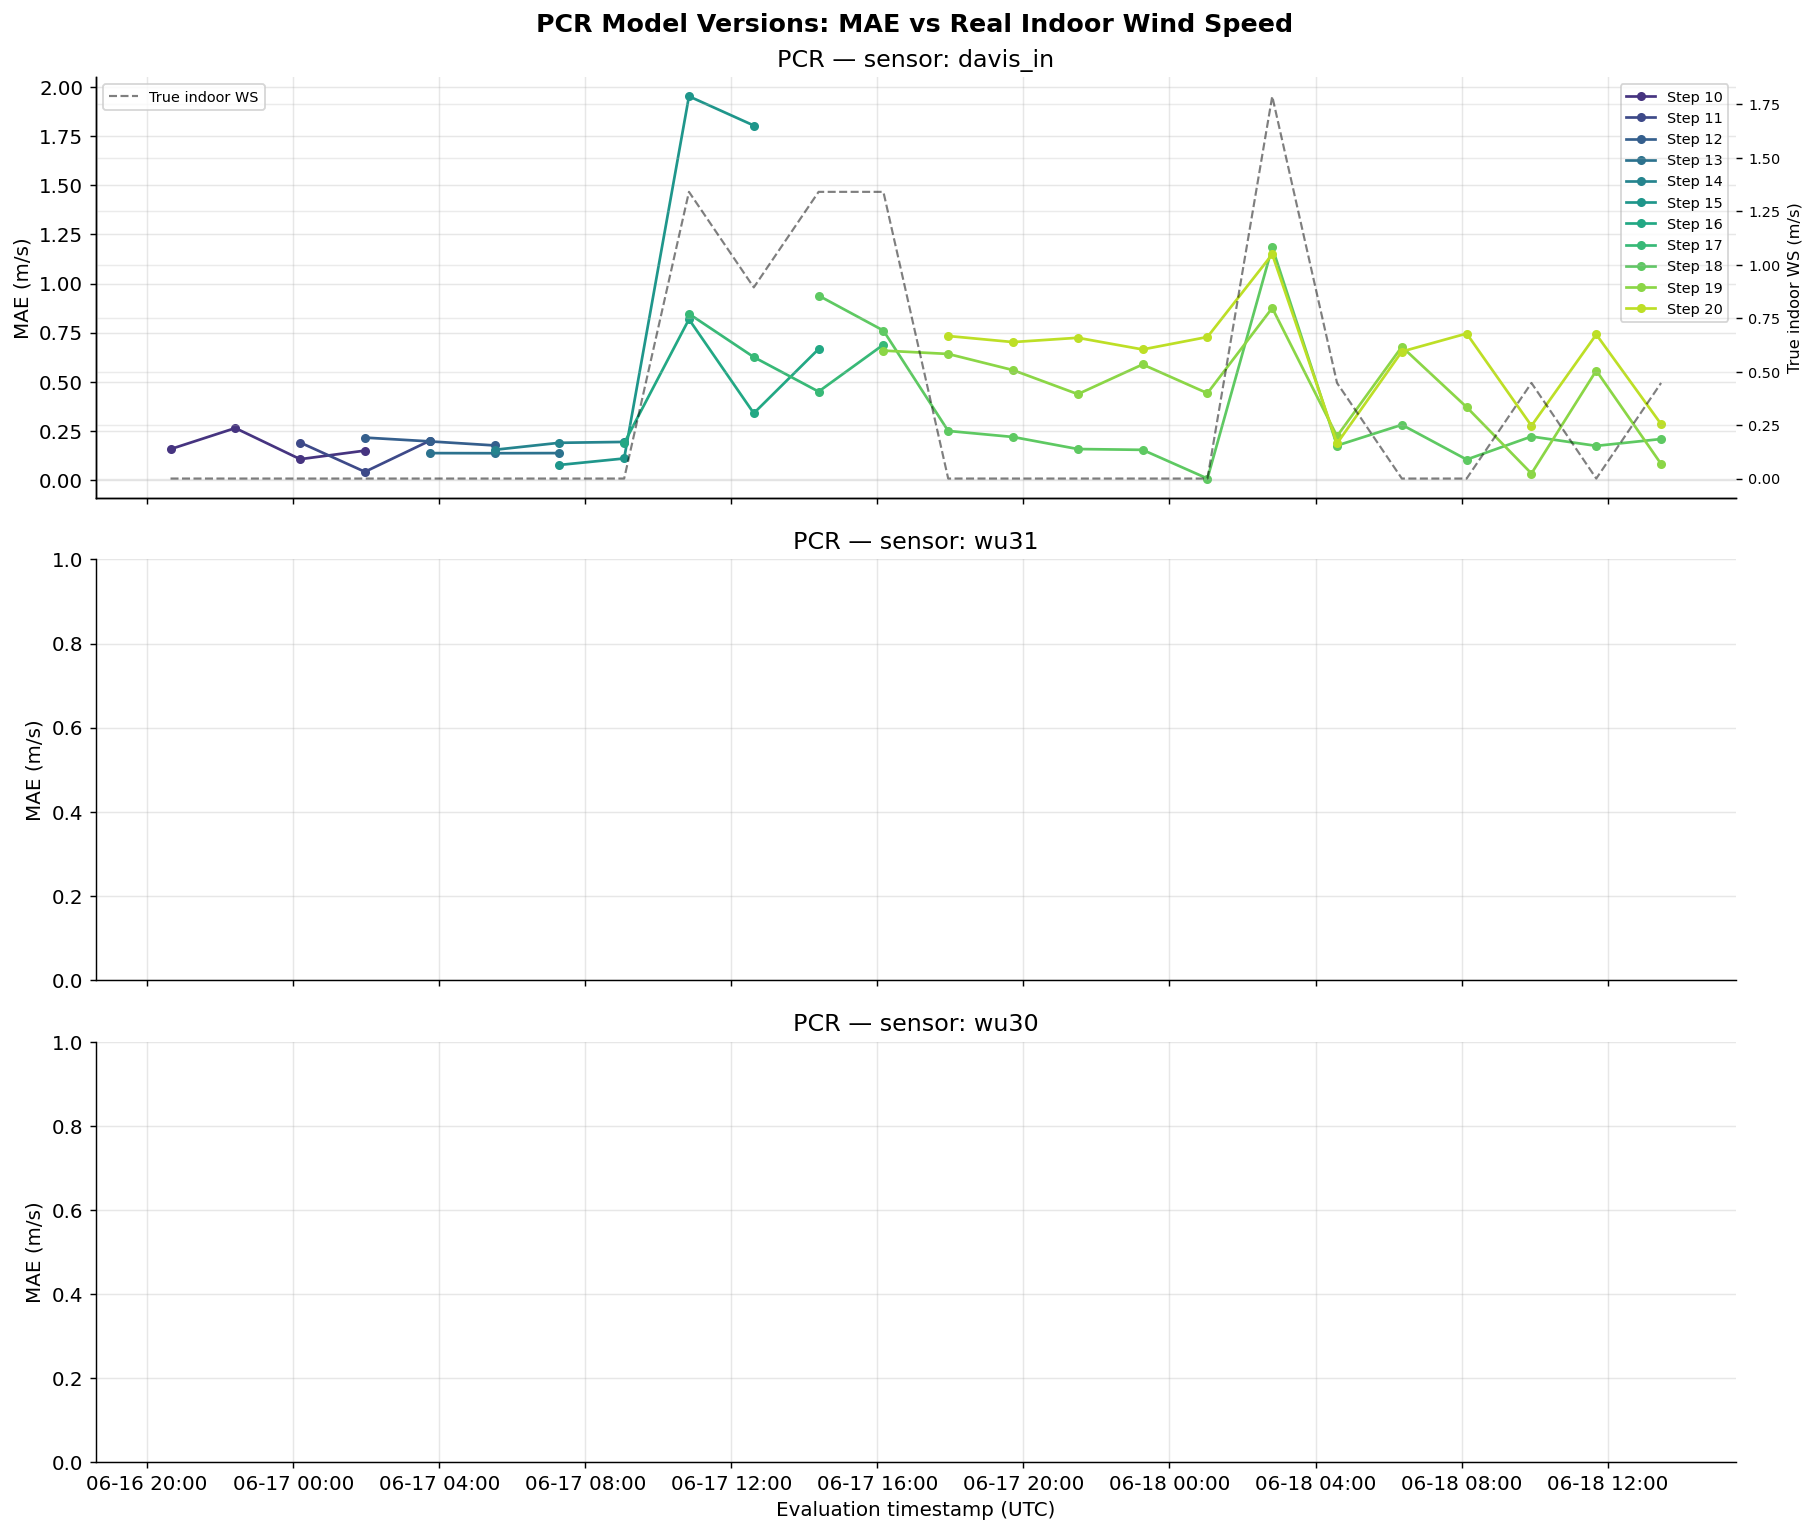

In [75]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

STEP_COLORS = plt.cm.viridis(np.linspace(0.15, 0.9, len(STEPS_EVAL)))
step_color_map = {s: STEP_COLORS[i] for i, s in enumerate(STEPS_EVAL)}

sensor_names = list(SENSORS.keys())
n_sensors    = len(sensor_names)

fig, axes = plt.subplots(n_sensors, 1, figsize=(14, 4 * n_sensors), sharex=True)
if n_sensors == 1:
    axes = [axes]

for ax, sname in zip(axes, sensor_names):
    # ── MAE lines (left axis) ──────────────────────────────────────────────
    for snum in sorted(edf["step_num"].unique()):
        sdf = edf[edf["step_num"] == snum].dropna(subset=[f"pcr_{sname}_mae"])
        if sdf.empty:
            continue
        sdf = sdf.sort_values("eval_dt")
        ax.plot(sdf["eval_dt"], sdf[f"pcr_{sname}_mae"],
                marker="o", ms=4, lw=1.5,
                color=step_color_map.get(snum, "gray"),
                label=f"Step {snum:02d}")

    ax.set_ylabel("MAE (m/s)")
    ax.set_title(f"PCR — sensor: {sname}")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

    # ── True sensor wind speed (right axis) ───────────────────────────────
    true_col = f"pcr_{sname}_true"
    # True value is identical across steps — deduplicate by timestamp
    true_vals = (edf.drop_duplicates(subset=["eval_dt"])
                    .sort_values("eval_dt")
                    .dropna(subset=[true_col]))
    if not true_vals.empty:
        ax2 = ax.twinx()
        ax2.plot(true_vals["eval_dt"], true_vals[true_col],
                 color="black", lw=1.2, ls="--", alpha=0.5, label="True indoor WS")
        ax2.set_ylabel("True indoor WS (m/s)", fontsize=9)
        ax2.tick_params(axis="y", labelsize=8)
        ax2.legend(loc="upper left", fontsize=8)

axes[0].legend(fontsize=8, loc="upper right")
axes[-1].set_xlabel("Evaluation timestamp (UTC)")
fig.suptitle("PCR Model Versions: MAE vs Real Indoor Wind Speed", fontsize=14, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


---
## 8  PINN Model Versions vs Real Indoor Wind Speed


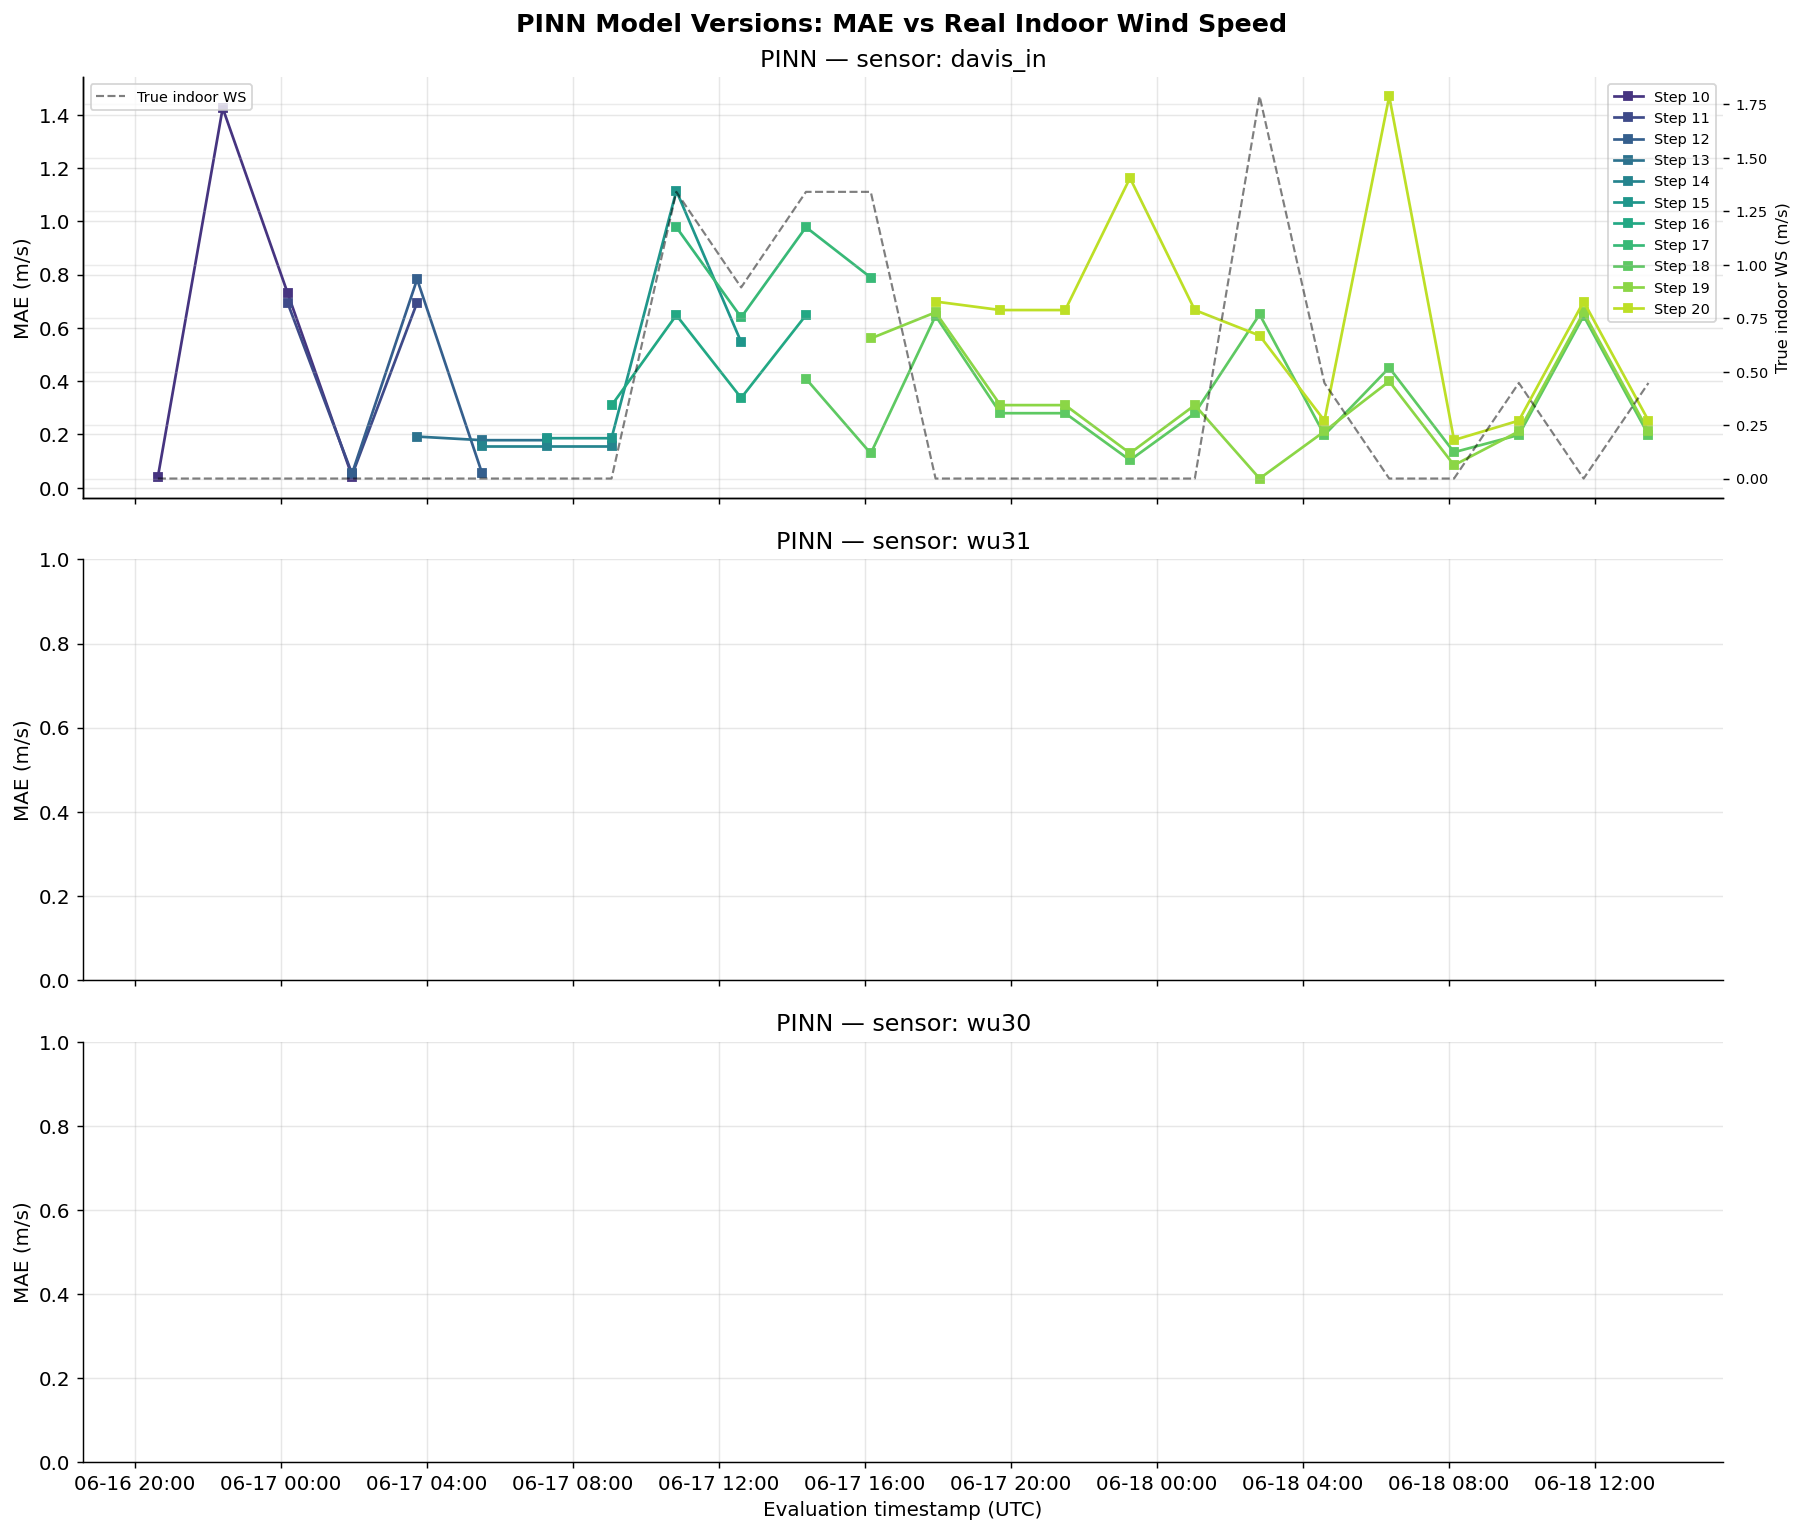

In [76]:
fig, axes = plt.subplots(n_sensors, 1, figsize=(14, 4 * n_sensors), sharex=True)
if n_sensors == 1:
    axes = [axes]

for ax, sname in zip(axes, sensor_names):
    # ── MAE lines (left axis) ──────────────────────────────────────────────
    for snum in sorted(edf["step_num"].unique()):
        sdf = edf[edf["step_num"] == snum].dropna(subset=[f"pinn_{sname}_mae"])
        if sdf.empty:
            continue
        sdf = sdf.sort_values("eval_dt")
        ax.plot(sdf["eval_dt"], sdf[f"pinn_{sname}_mae"],
                marker="s", ms=4, lw=1.5,
                color=step_color_map.get(snum, "gray"),
                label=f"Step {snum:02d}")

    ax.set_ylabel("MAE (m/s)")
    ax.set_title(f"PINN — sensor: {sname}")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

    # ── True sensor wind speed (right axis) ───────────────────────────────
    true_col = f"pinn_{sname}_true"
    # True value is identical across steps — deduplicate by timestamp
    true_vals = (edf.drop_duplicates(subset=["eval_dt"])
                    .sort_values("eval_dt")
                    .dropna(subset=[true_col]))
    if not true_vals.empty:
        ax2 = ax.twinx()
        ax2.plot(true_vals["eval_dt"], true_vals[true_col],
                 color="black", lw=1.2, ls="--", alpha=0.5, label="True indoor WS")
        ax2.set_ylabel("True indoor WS (m/s)", fontsize=9)
        ax2.tick_params(axis="y", labelsize=8)
        ax2.legend(loc="upper left", fontsize=8)

axes[0].legend(fontsize=8, loc="upper right")
axes[-1].set_xlabel("Evaluation timestamp (UTC)")
fig.suptitle("PINN Model Versions: MAE vs Real Indoor Wind Speed", fontsize=14, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


---
## 9  FNO Model Versions vs Real Indoor Wind Speed


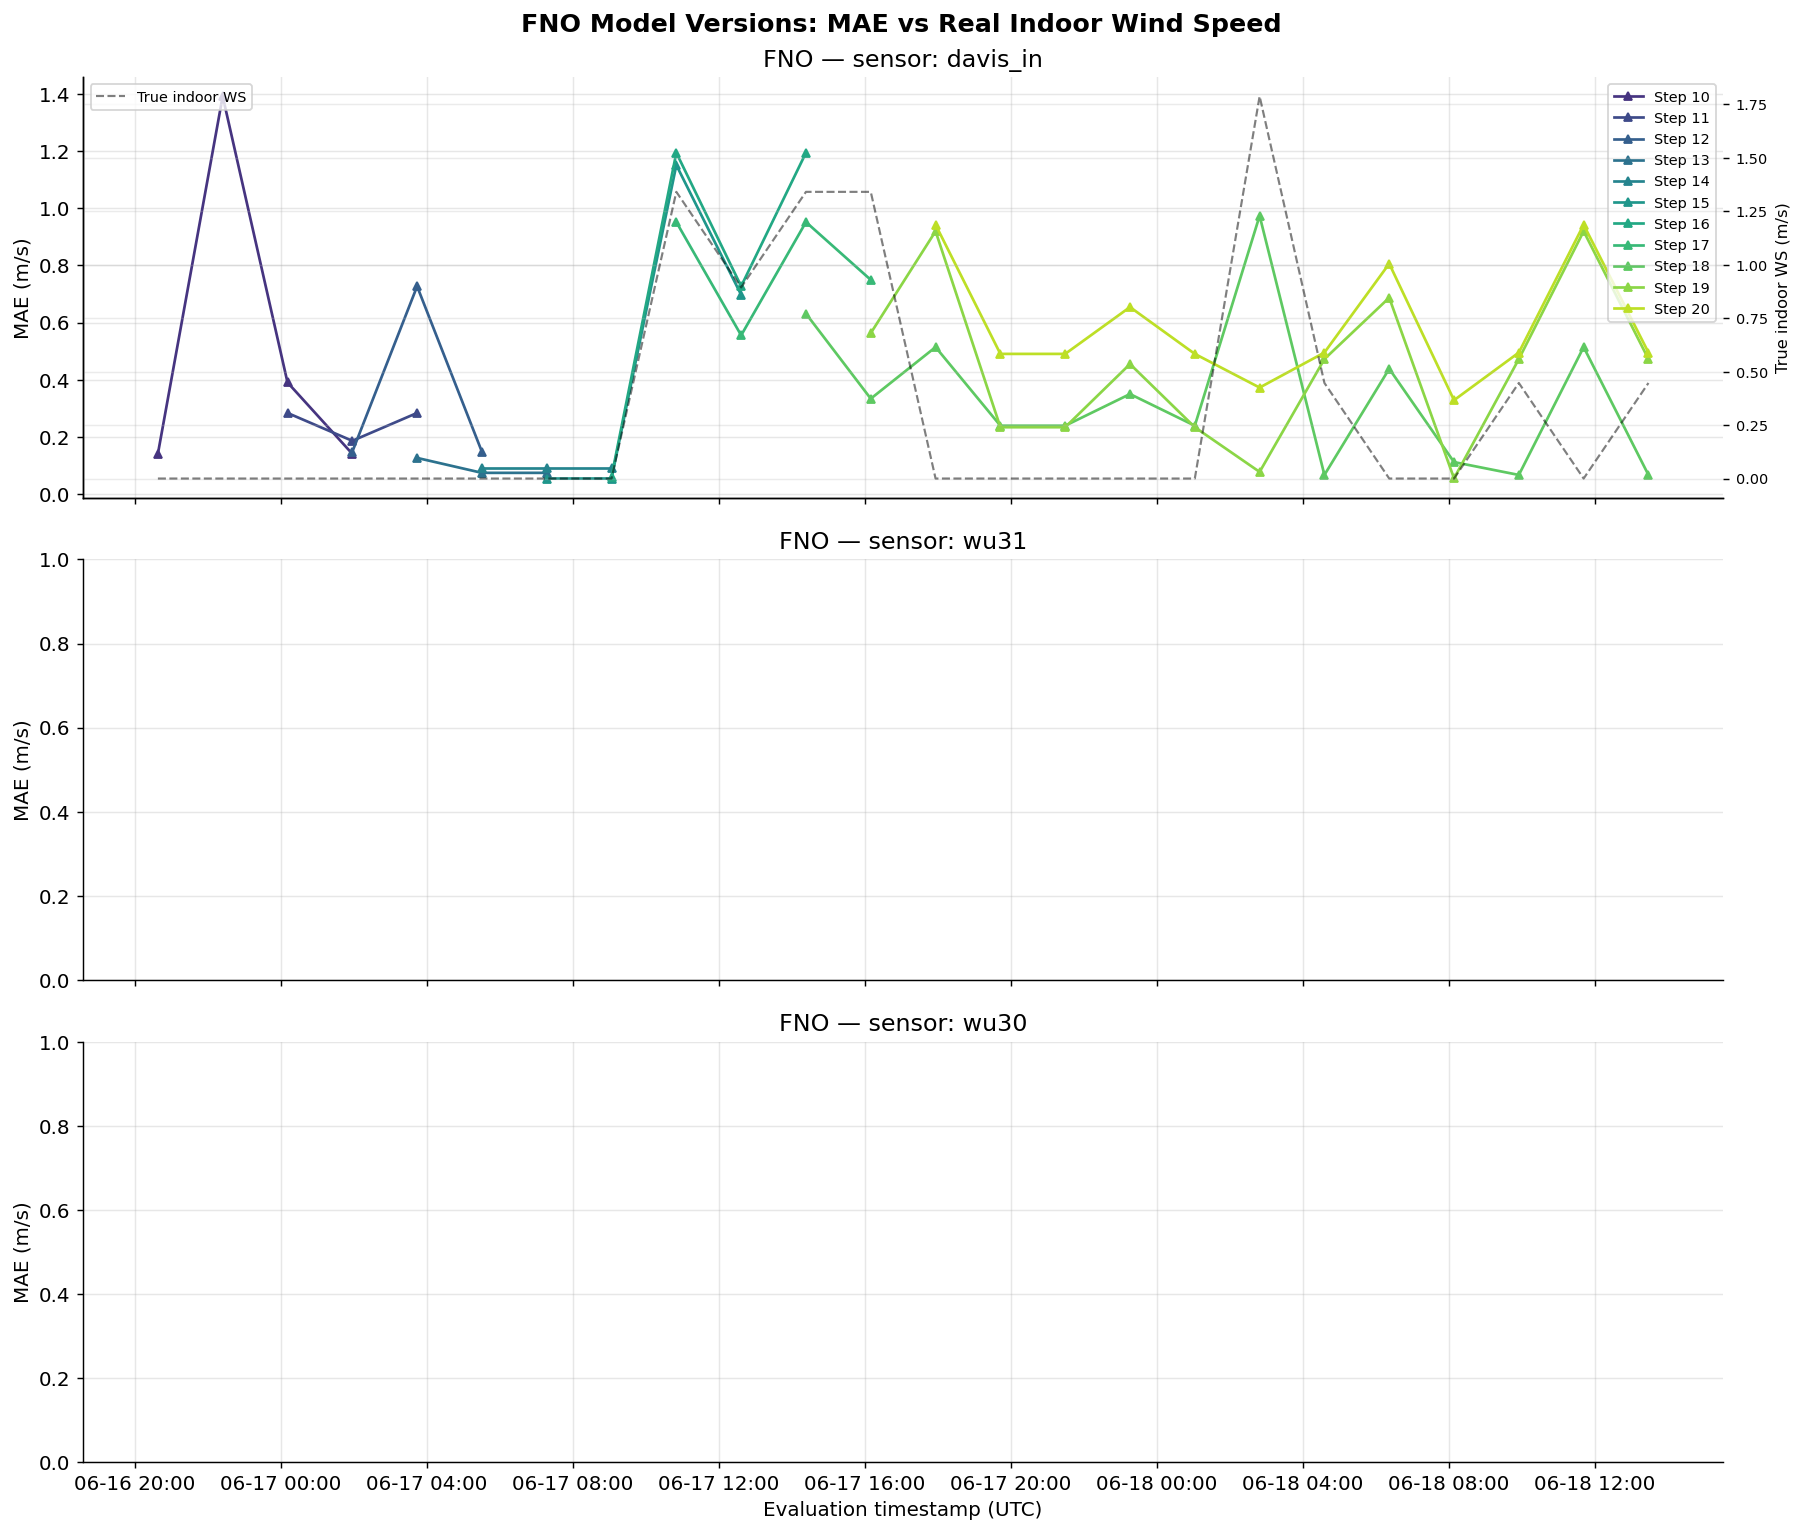

In [77]:
fig, axes = plt.subplots(n_sensors, 1, figsize=(14, 4 * n_sensors), sharex=True)
if n_sensors == 1:
    axes = [axes]

for ax, sname in zip(axes, sensor_names):
    # ── MAE lines (left axis) ──────────────────────────────────────────────
    for snum in sorted(edf["step_num"].unique()):
        sdf = edf[edf["step_num"] == snum].dropna(subset=[f"fno_{sname}_mae"])
        if sdf.empty:
            continue
        sdf = sdf.sort_values("eval_dt")
        ax.plot(sdf["eval_dt"], sdf[f"fno_{sname}_mae"],
                marker="^", ms=4, lw=1.5,
                color=step_color_map.get(snum, "gray"),
                label=f"Step {snum:02d}")

    ax.set_ylabel("MAE (m/s)")
    ax.set_title(f"FNO — sensor: {sname}")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

    # ── True sensor wind speed (right axis) ───────────────────────────────
    true_col = f"fno_{sname}_true"
    # True value is identical across steps — deduplicate by timestamp
    true_vals = (edf.drop_duplicates(subset=["eval_dt"])
                    .sort_values("eval_dt")
                    .dropna(subset=[true_col]))
    if not true_vals.empty:
        ax2 = ax.twinx()
        ax2.plot(true_vals["eval_dt"], true_vals[true_col],
                 color="black", lw=1.2, ls="--", alpha=0.5, label="True indoor WS")
        ax2.set_ylabel("True indoor WS (m/s)", fontsize=9)
        ax2.tick_params(axis="y", labelsize=8)
        ax2.legend(loc="upper left", fontsize=8)

axes[0].legend(fontsize=8, loc="upper right")
axes[-1].set_xlabel("Evaluation timestamp (UTC)")
fig.suptitle("FNO Model Versions: MAE vs Real Indoor Wind Speed", fontsize=14, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


---
## 10  Combined: Group MAE Over Time & Summary Table

**Left**: Mean MAE across all sensors for each model group (step), aggregated over eval timestamps.
Each step is shown as a bar — lower = better.

**Right**: Summary table — mean/median/min MAE per step per model type.


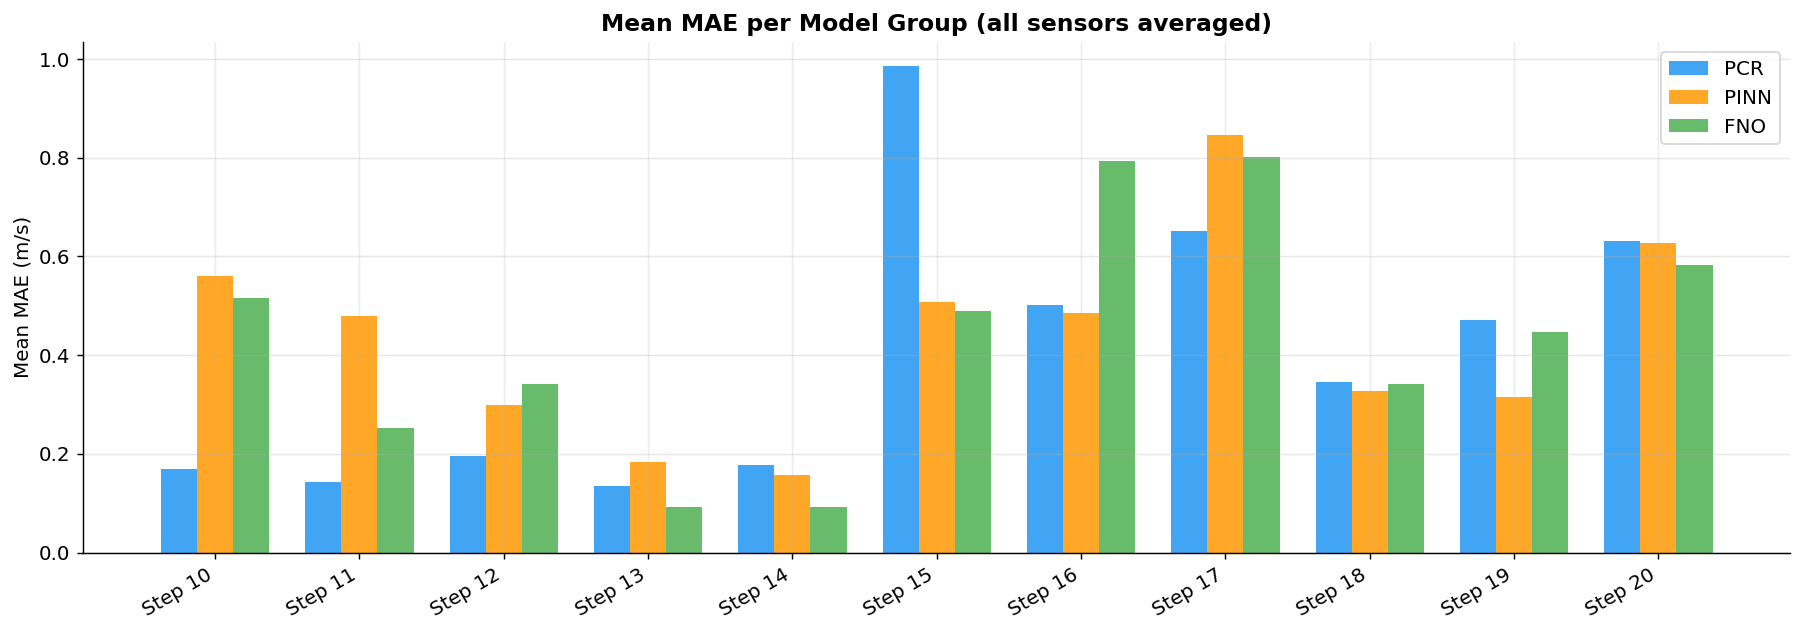

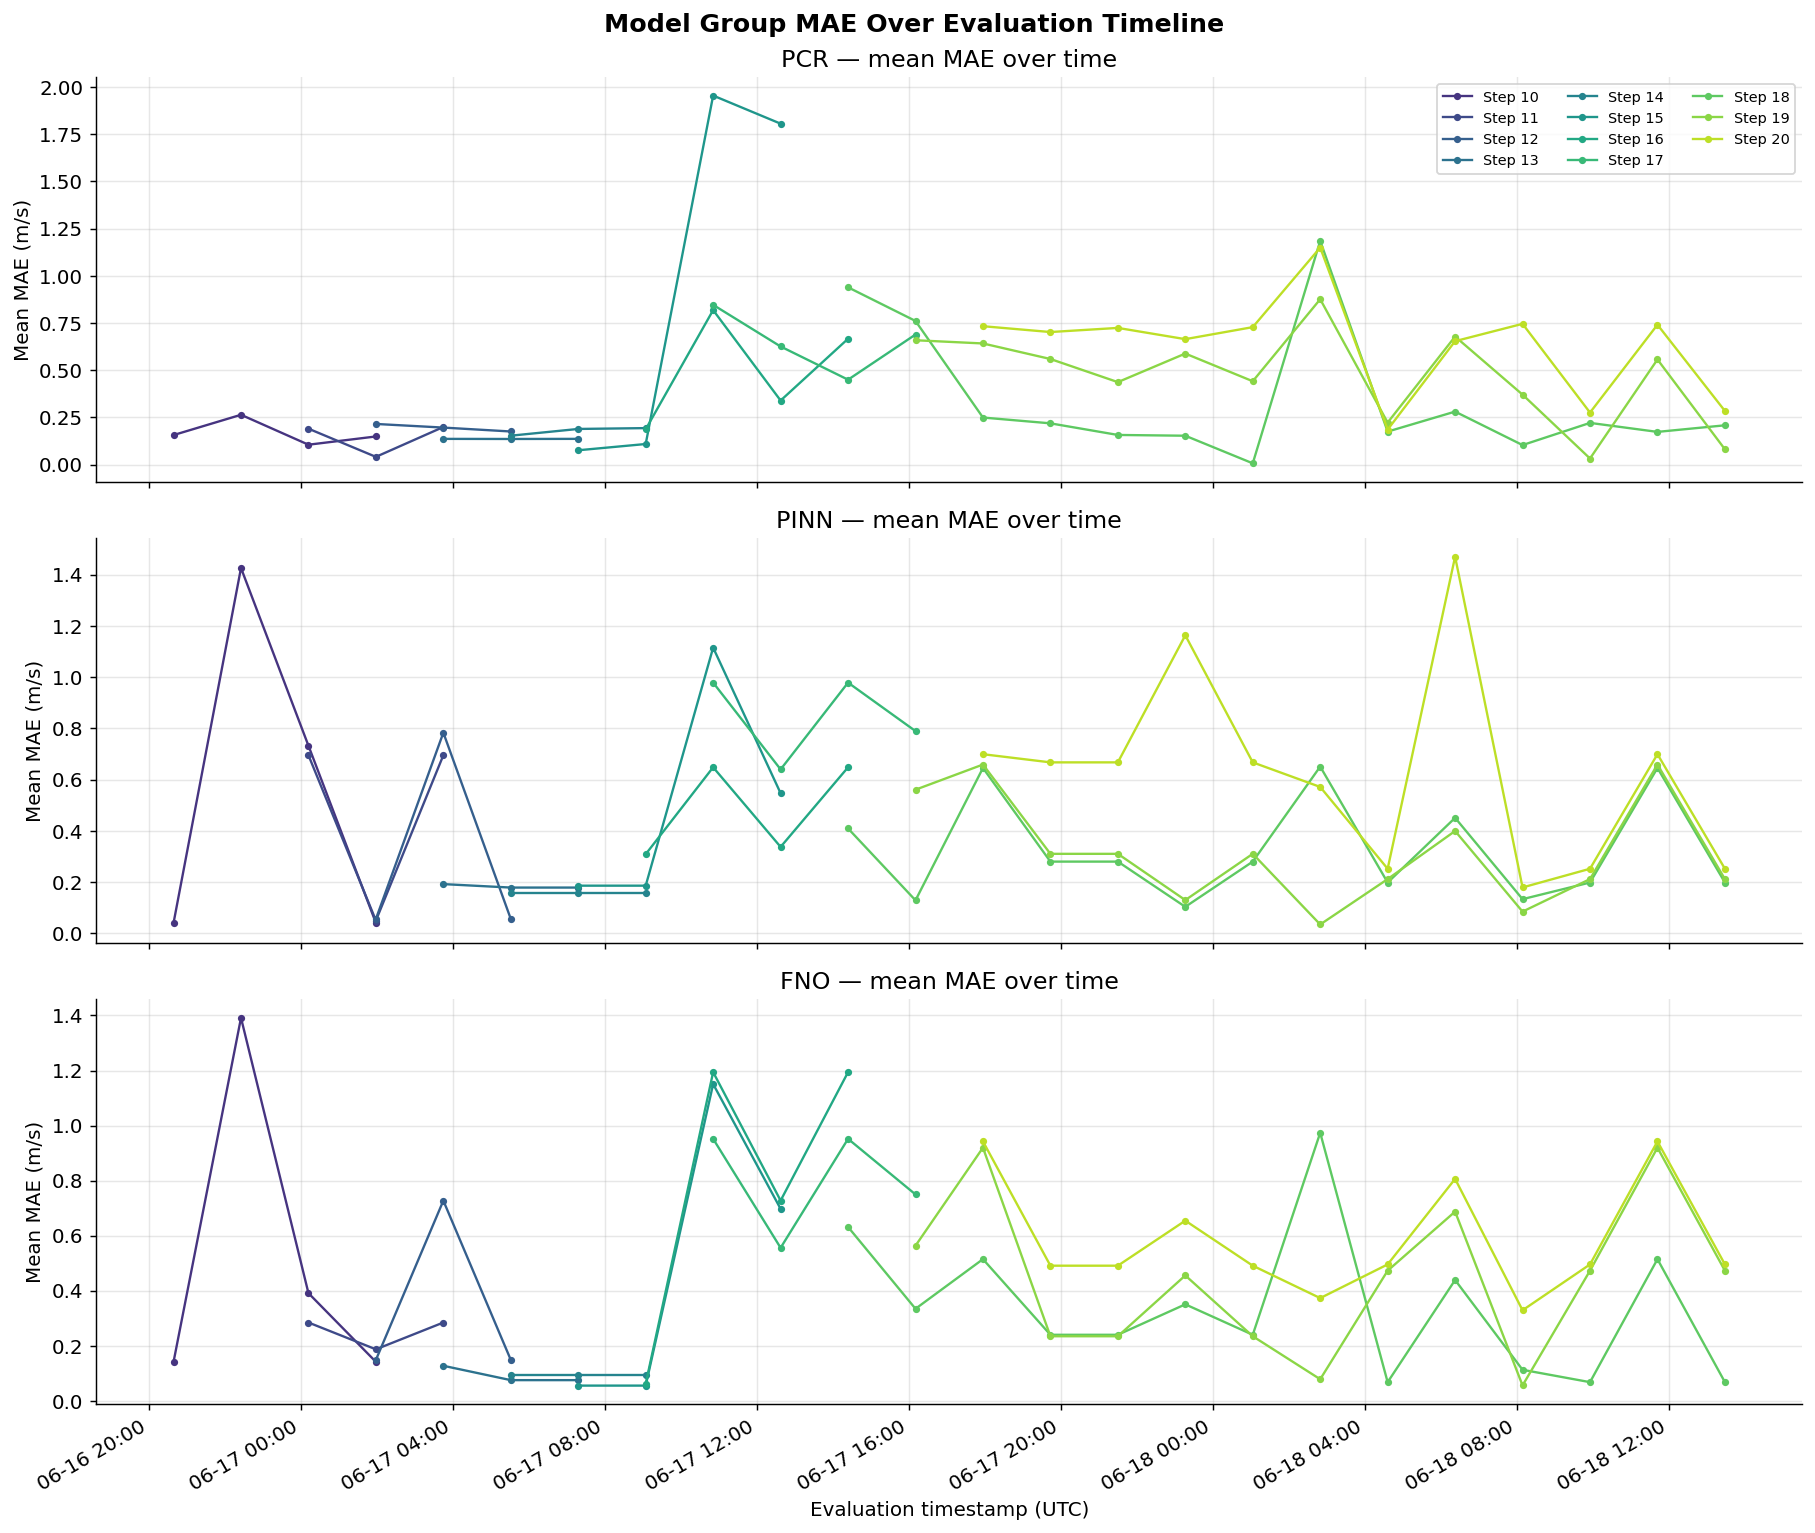

,Cutoff,PCR MAE mean,PCR MAE min,PINN MAE mean,PINN MAE min,FNO MAE mean,FNO MAE min
Step,,,,,,,
10,06-16 20:38,0.168500,0.105200,0.559600,0.040500,0.516100,0.141200
11,06-16 22:40,0.143300,0.040800,0.479800,0.049700,0.251600,0.186700
12,06-17 00:41,0.195400,0.175200,0.298100,0.055800,0.341200,0.148300
13,06-17 02:43,0.135900,0.135500,0.182900,0.178300,0.092100,0.074700
14,06-17 04:45,0.178200,0.152900,0.158200,0.158200,0.093100,0.093100
15,06-17 06:46,0.985900,0.075700,0.508200,0.185700,0.489400,0.054800
16,06-17 08:48,0.502500,0.186700,0.485300,0.308600,0.794200,0.061500
17,06-17 10:50,0.652300,0.449400,0.846200,0.639500,0.802100,0.555600
18,06-17 12:52,0.344800,0.006500,0.328400,0.103200,0.342100,0.067400


In [78]:
# ── 10a: Group-level mean MAE bar chart ──────────────────────────────────────
model_types = ["pcr", "pinn", "fno"]
mt_labels   = {"pcr": "PCR", "pinn": "PINN", "fno": "FNO"}
mt_colors   = {"pcr": "#2196F3", "pinn": "#FF9800", "fno": "#4CAF50"}

steps_sorted = sorted(edf["step_num"].unique())
n_steps  = len(steps_sorted)
x        = np.arange(n_steps)
bar_w    = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
for mi, mt in enumerate(model_types):
    means = []
    for snum in steps_sorted:
        sdf = edf[edf["step_num"] == snum]
        cols = [f"{mt}_{sn}_mae" for sn in sensor_names if f"{mt}_{sn}_mae" in sdf.columns]
        vals = sdf[cols].values.flatten()
        vals = vals[~np.isnan(vals)]
        means.append(float(np.mean(vals)) if len(vals) > 0 else np.nan)
    ax.bar(x + mi * bar_w, means, bar_w, label=mt_labels[mt], color=mt_colors[mt], alpha=0.85)

ax.set_xticks(x + bar_w)
ax.set_xticklabels([f"Step {s}" for s in steps_sorted], rotation=30, ha="right")
ax.set_ylabel("Mean MAE (m/s)")
ax.set_title("Mean MAE per Model Group (all sensors averaged)", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── 10b: MAE over time — group mean per model type ───────────────────────────
fig, axes = plt.subplots(len(model_types), 1, figsize=(14, 4 * len(model_types)), sharex=True)
for ax, mt in zip(axes, model_types):
    for snum in steps_sorted:
        sdf = edf[edf["step_num"] == snum].sort_values("eval_dt")
        cols = [f"{mt}_{sn}_mae" for sn in sensor_names if f"{mt}_{sn}_mae" in sdf.columns]
        row_means = sdf[cols].mean(axis=1)
        valid = row_means.dropna()
        if valid.empty:
            continue
        ax.plot(sdf.loc[valid.index, "eval_dt"], valid,
                marker="o", ms=3, lw=1.3,
                color=step_color_map.get(snum, "gray"),
                label=f"Step {snum:02d}")
    ax.set_ylabel("Mean MAE (m/s)")
    ax.set_title(f"{mt_labels[mt]} — mean MAE over time")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

axes[0].legend(fontsize=8, ncol=3, loc="upper right")
axes[-1].set_xlabel("Evaluation timestamp (UTC)")
fig.suptitle("Model Group MAE Over Evaluation Timeline", fontsize=14, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ── 10c: Summary table ────────────────────────────────────────────────────────
summary_rows = []
for snum in steps_sorted:
    sdf  = edf[edf["step_num"] == snum]
    row  = {"Step": snum}
    if snum in model_store:
        row["Cutoff"] = model_store[snum]["cutoff"].strftime("%m-%d %H:%M")
    for mt in model_types:
        cols = [f"{mt}_{sn}_mae" for sn in sensor_names if f"{mt}_{sn}_mae" in sdf.columns]
        vals = sdf[cols].values.flatten()
        vals = vals[~np.isnan(vals)]
        row[f"{mt_labels[mt]} MAE mean"] = round(float(np.mean(vals)), 4) if len(vals) else np.nan
        row[f"{mt_labels[mt]} MAE min"]  = round(float(np.min(vals)), 4)  if len(vals) else np.nan
    summary_rows.append(row)

sdf_summary = pd.DataFrame(summary_rows).set_index("Step")

def _color_col(s):
    valid = s.dropna()
    if valid.empty:
        return [""] * len(s)
    mn, mx = valid.min(), valid.max()
    def _c(v):
        if pd.isna(v): return ""
        t = (v - mn) / (mx - mn + 1e-12)
        r = int(255 * t); g = int(255 * (1 - t))
        return f"background-color: rgb({r},{g},100)"
    return [_c(v) for v in s]

mean_cols = [c for c in sdf_summary.columns if "mean" in c]
display(sdf_summary.style.apply(_color_col, subset=mean_cols)
        .set_caption("Summary: Mean & Min MAE per Step per Model Type (green = lower = better)")
        .format(na_rep="—"))


In [ ]:
w